# Employee Attrition Visualizations
These charts are generated directly inside this notebook (VS Code output cells).

Order:
1. Class imbalance (original)
2. Class balance after SMOTE
3. Correlation heatmap
4. Attrition by overtime
5. Attrition by job satisfaction
6. Attrition by work-life balance
7. Age by attrition
8. Monthly income by attrition
9. Years at company by attrition
10. Top feature correlations with attrition

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='deep')

df = pd.read_csv(r'C:\Users\Lavender\Desktop\ibm_attrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
# Prepare encoded data and SMOTE counts for plotting
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')

df_enc = df.copy()
for c in cat_cols:
    df_enc[c] = LabelEncoder().fit_transform(df[c])
df_enc['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

feature_cols = [c for c in df_enc.columns if c not in ['Attrition', 'Attrition_bin']]
X = df_enc[feature_cols]
y = df_enc['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train)

X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_train)

print('Before SMOTE:', np.bincount(y_train))
print('After SMOTE :', np.bincount(y_res))

C:\Users\Lavender\AppData\Local\Temp\ipykernel_26592\4031166915.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Before SMOTE: [986 190]
After SMOTE : [986 986]


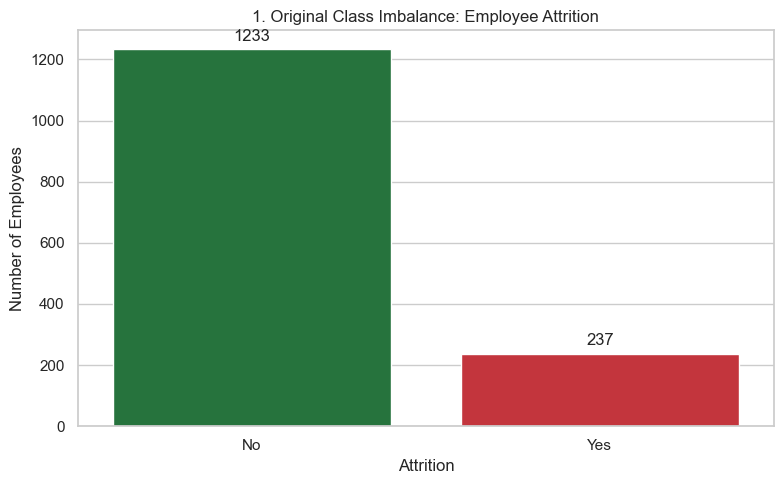

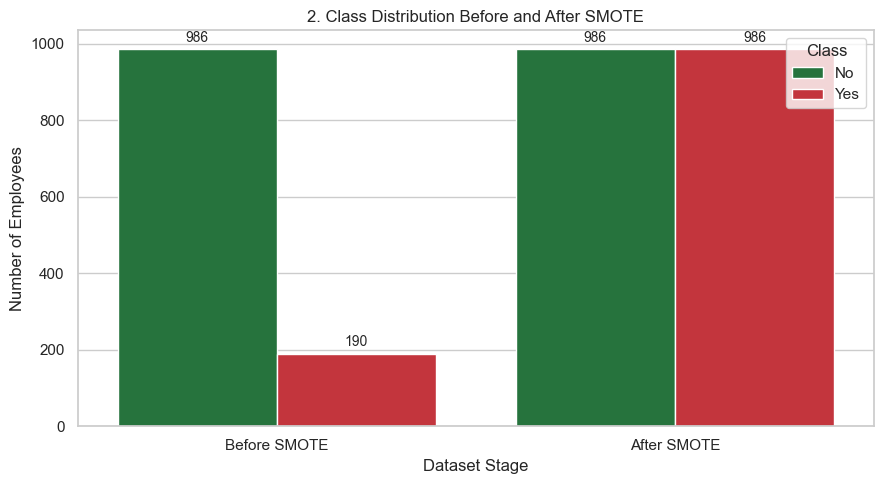

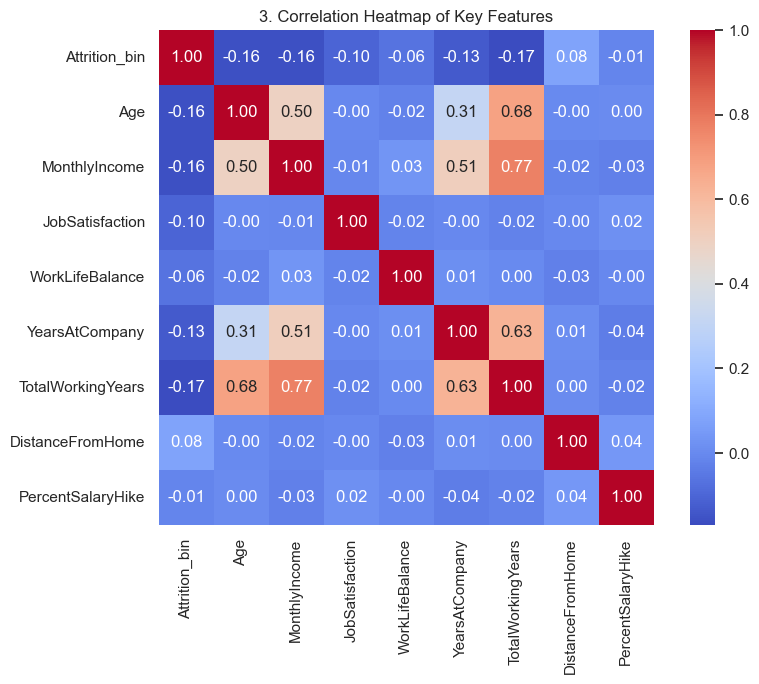

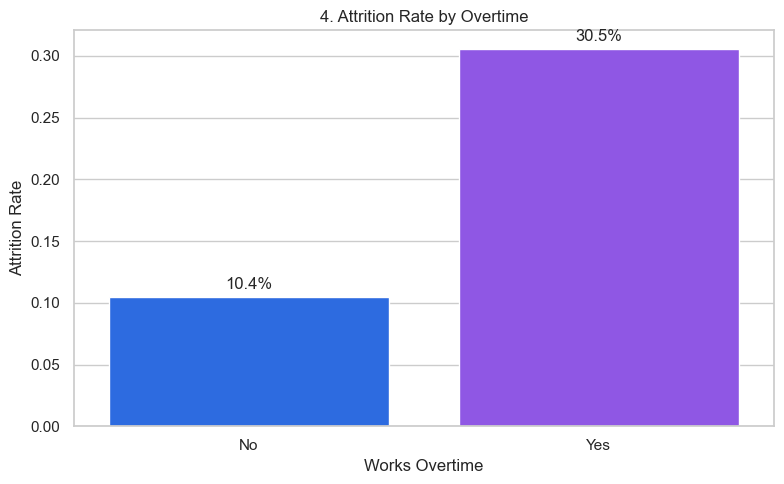

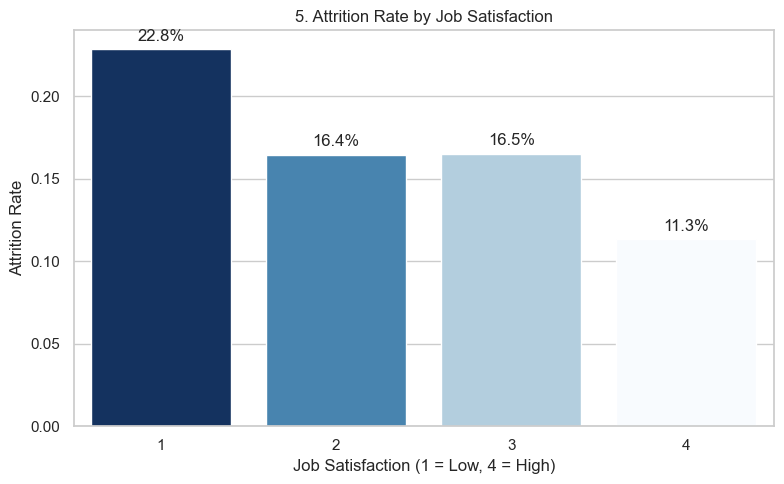

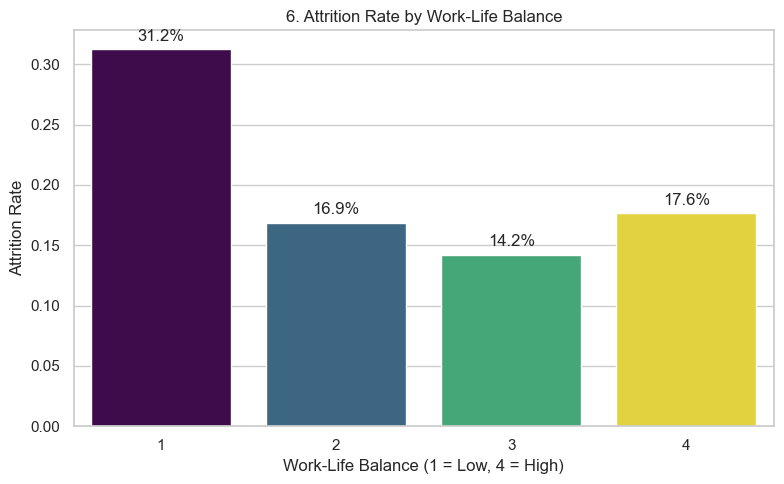

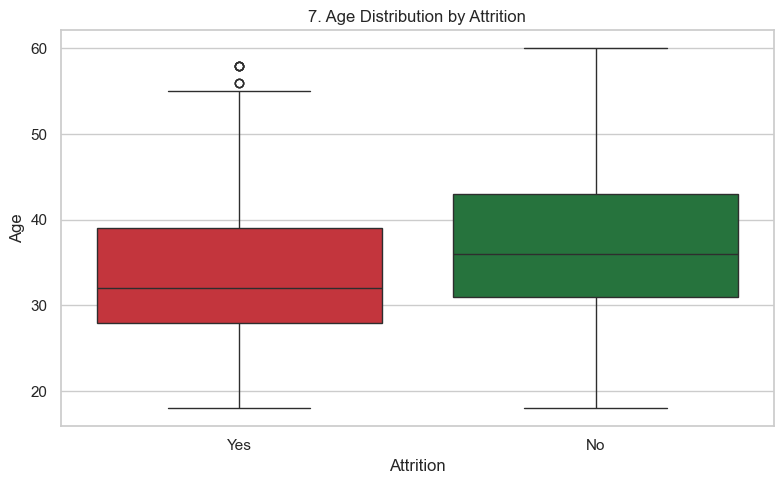

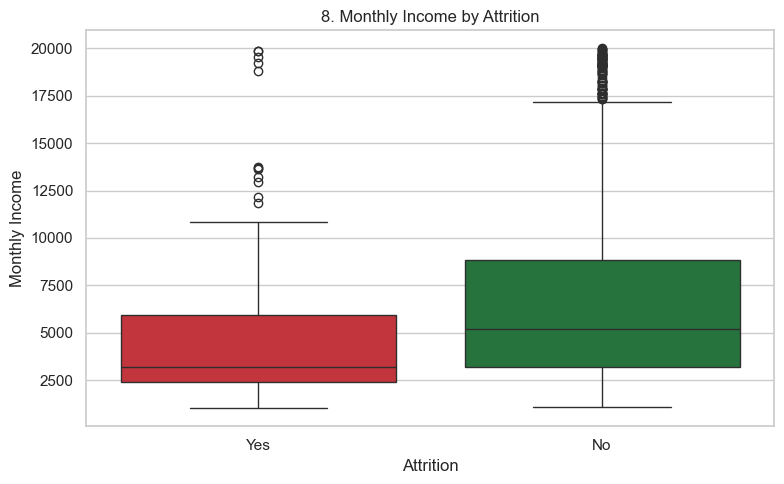

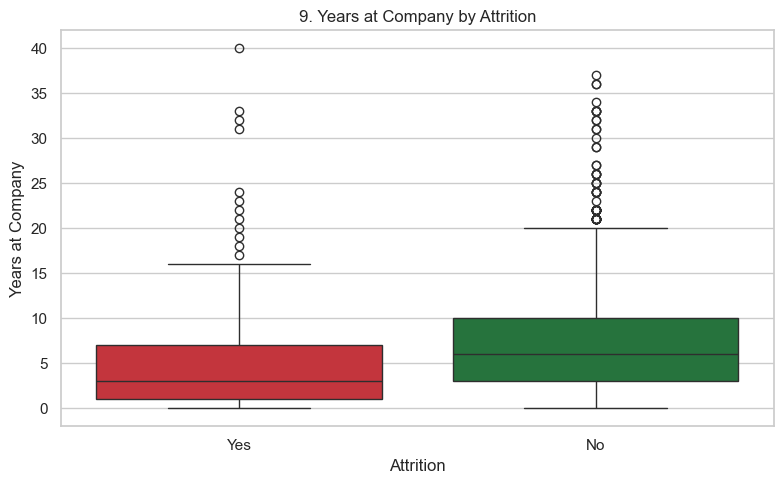

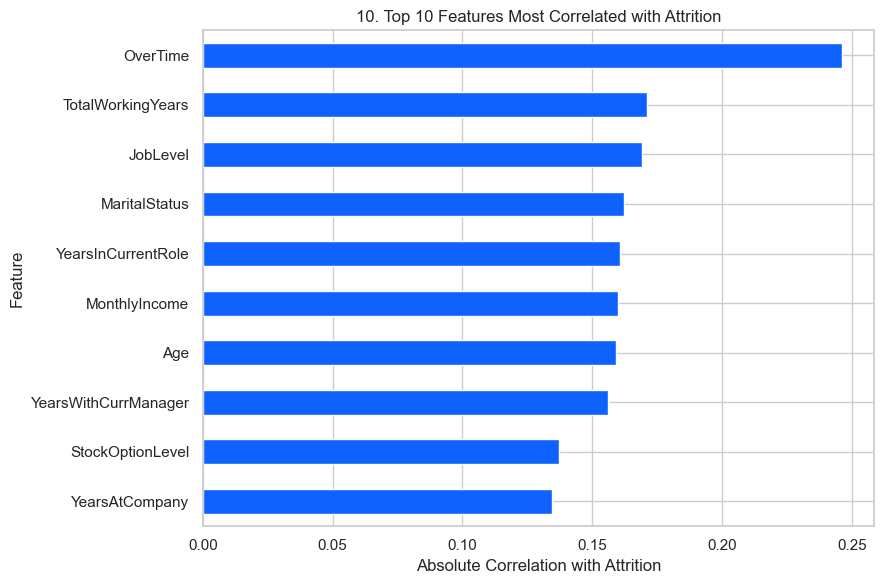

In [9]:
# 1) Class imbalance (original)
class_counts = df['Attrition'].value_counts().rename_axis('Attrition').reset_index(name='Count')
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=class_counts, x='Attrition', y='Count', hue='Attrition', dodge=False,
                 palette={'No': '#198038', 'Yes': '#DA1E28'})
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('1. Original Class Imbalance: Employee Attrition')
ax.set_xlabel('Attrition')
ax.set_ylabel('Number of Employees')
for patch, count in zip(ax.patches, class_counts['Count']):
    ax.annotate(f'{count}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# 2) Class balance before/after SMOTE
smote_counts = pd.DataFrame({
    'Stage': ['Before SMOTE', 'Before SMOTE', 'After SMOTE', 'After SMOTE'],
    'Class': ['No', 'Yes', 'No', 'Yes'],
    'Count': [int((y_train == 0).sum()), int((y_train == 1).sum()),
              int((y_res == 0).sum()), int((y_res == 1).sum())],
})
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=smote_counts, x='Stage', y='Count', hue='Class',
                 palette={'No': '#198038', 'Yes': '#DA1E28'})
ax.set_title('2. Class Distribution Before and After SMOTE')
ax.set_xlabel('Dataset Stage')
ax.set_ylabel('Number of Employees')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)
plt.tight_layout()
plt.show()

# 3) Correlation heatmap
corr_cols = ['Attrition_bin', 'Age', 'MonthlyIncome', 'JobSatisfaction',
             'WorkLifeBalance', 'YearsAtCompany', 'TotalWorkingYears',
             'DistanceFromHome', 'PercentSalaryHike']
corr_matrix = df_enc[corr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('3. Correlation Heatmap of Key Features')
plt.tight_layout()
plt.show()

# 4) Attrition rate by overtime
overtime_rates = (df.groupby('OverTime')['Attrition']
                    .apply(lambda values: (values == 'Yes').mean())
                    .reset_index(name='AttritionRate'))
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=overtime_rates, x='OverTime', y='AttritionRate', hue='OverTime',
                 dodge=False, palette={'No': '#0F62FE', 'Yes': '#8A3FFC'})
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('4. Attrition Rate by Overtime')
ax.set_xlabel('Works Overtime')
ax.set_ylabel('Attrition Rate')
for patch, rate in zip(ax.patches, overtime_rates['AttritionRate']):
    ax.annotate(f'{rate:.1%}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# 5) Attrition rate by job satisfaction
satisfaction_rates = (df.groupby('JobSatisfaction')['Attrition']
                        .apply(lambda values: (values == 'Yes').mean())
                        .reset_index(name='AttritionRate'))
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=satisfaction_rates, x='JobSatisfaction', y='AttritionRate',
                 hue='JobSatisfaction', dodge=False, palette='Blues_r')
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('5. Attrition Rate by Job Satisfaction')
ax.set_xlabel('Job Satisfaction (1 = Low, 4 = High)')
ax.set_ylabel('Attrition Rate')
for patch, rate in zip(ax.patches, satisfaction_rates['AttritionRate']):
    ax.annotate(f'{rate:.1%}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# 6) Attrition rate by work-life balance
worklife_rates = (df.groupby('WorkLifeBalance')['Attrition']
                    .apply(lambda values: (values == 'Yes').mean())
                    .reset_index(name='AttritionRate'))
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=worklife_rates, x='WorkLifeBalance', y='AttritionRate',
                 hue='WorkLifeBalance', dodge=False, palette='viridis')
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('6. Attrition Rate by Work-Life Balance')
ax.set_xlabel('Work-Life Balance (1 = Low, 4 = High)')
ax.set_ylabel('Attrition Rate')
for patch, rate in zip(ax.patches, worklife_rates['AttritionRate']):
    ax.annotate(f'{rate:.1%}',
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

# 7) Age boxplot by attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='Age', hue='Attrition', dodge=False,
            palette={'No': '#198038', 'Yes': '#DA1E28'})
plt.title('7. Age Distribution by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')
legend = plt.gca().legend_
if legend is not None:
    legend.remove()
plt.tight_layout()
plt.show()

# 8) Monthly income boxplot by attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', dodge=False,
            palette={'No': '#198038', 'Yes': '#DA1E28'})
plt.title('8. Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
legend = plt.gca().legend_
if legend is not None:
    legend.remove()
plt.tight_layout()
plt.show()

# 9) Years at company boxplot by attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', hue='Attrition', dodge=False,
            palette={'No': '#198038', 'Yes': '#DA1E28'})
plt.title('9. Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
legend = plt.gca().legend_
if legend is not None:
    legend.remove()
plt.tight_layout()
plt.show()

# 10) Top feature correlations with attrition
feature_target_corr = (df_enc.corr(numeric_only=True)['Attrition_bin']
                       .drop('Attrition_bin')
                       .abs()
                       .sort_values(ascending=False)
                       .head(10)
                       .sort_values())
plt.figure(figsize=(9, 6))
ax = feature_target_corr.plot(kind='barh', color='#0F62FE')
ax.set_title('10. Top 10 Features Most Correlated with Attrition')
ax.set_xlabel('Absolute Correlation with Attrition')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 11) Feature Exploration and Analysis
This section expands EDA to analyze:
- job-related factors and their correlation with attrition
- demographic effects (Age, Education)
- class separation in continuous variables
- model-based feature importance

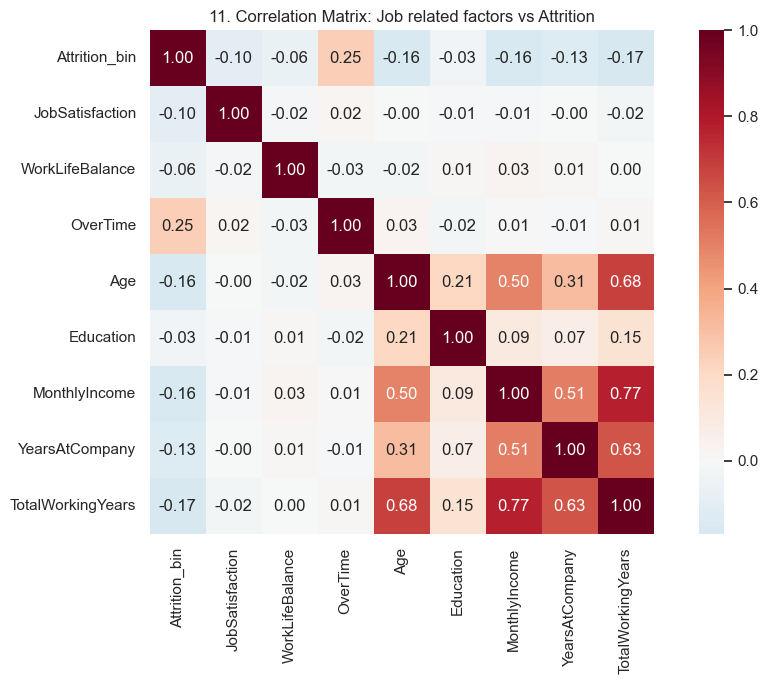

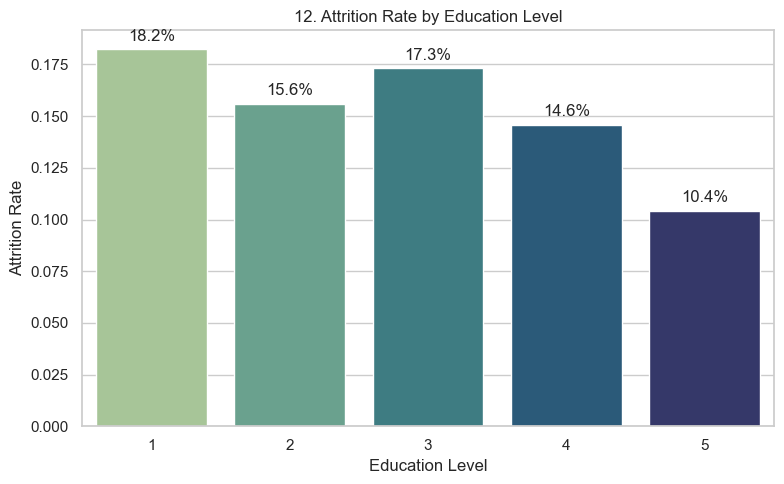

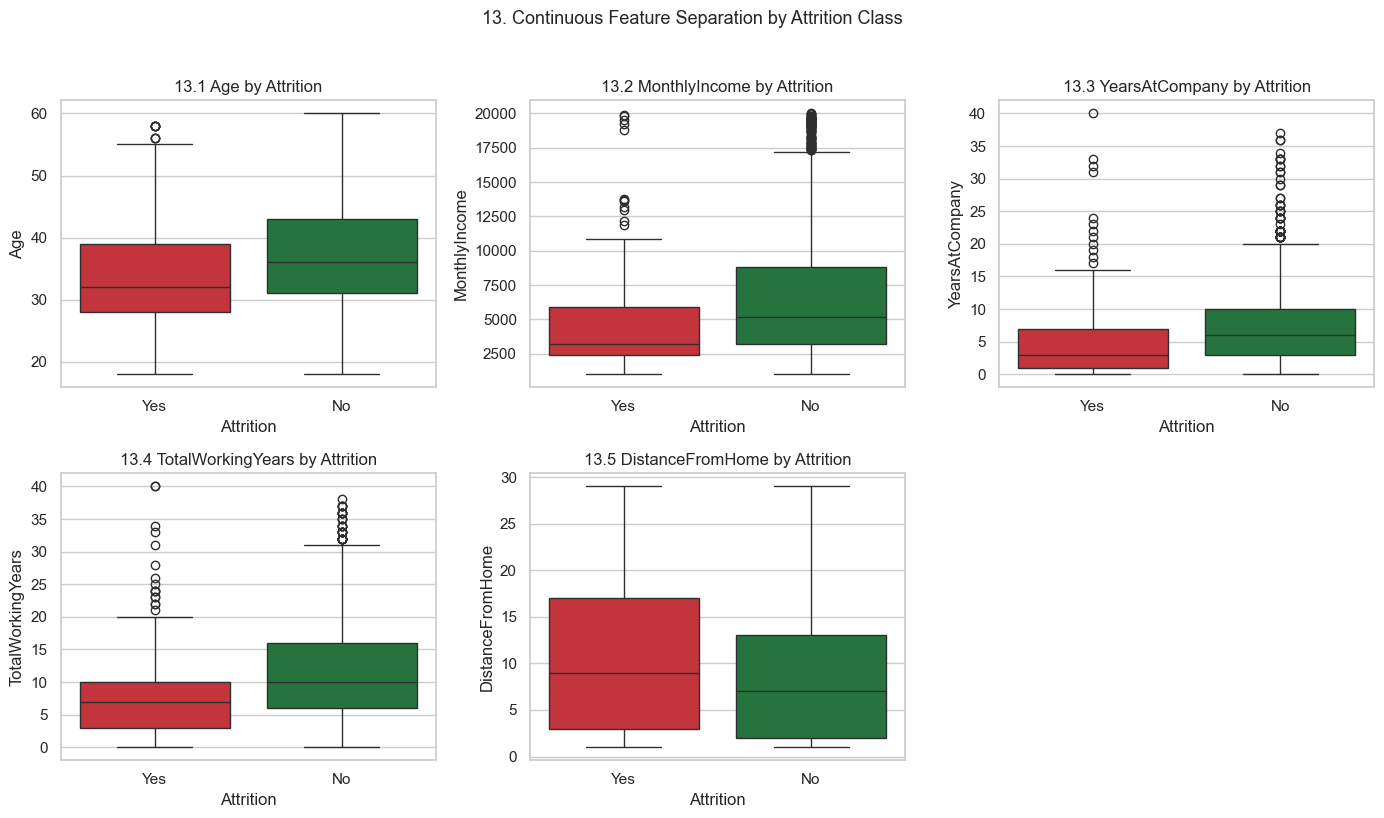

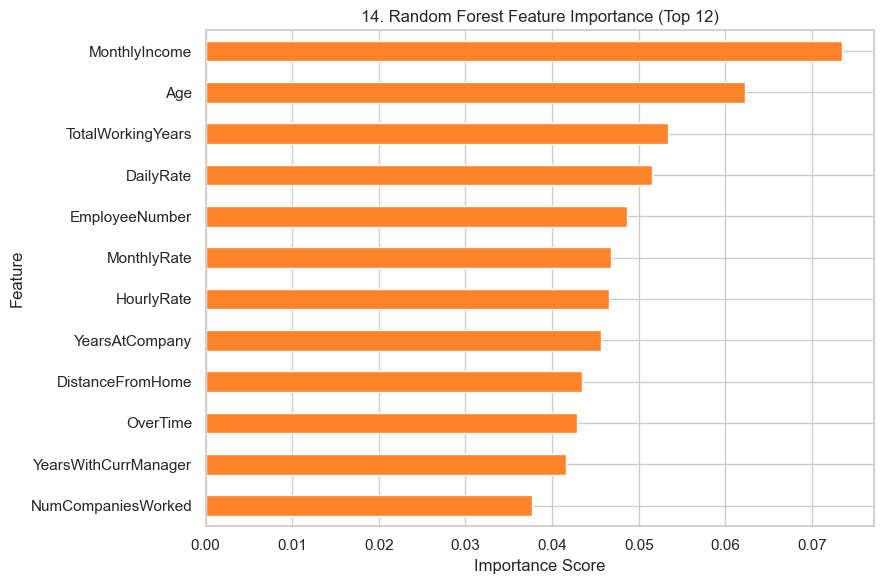

Top 12 Random Forest Features:
MonthlyIncome           0.073464
Age                     0.062292
TotalWorkingYears       0.053348
DailyRate               0.051481
EmployeeNumber          0.048631
MonthlyRate             0.046772
HourlyRate              0.046508
YearsAtCompany          0.045630
DistanceFromHome        0.043402
OverTime                0.042820
YearsWithCurrManager    0.041567
NumCompaniesWorked      0.037691
dtype: float64


In [10]:
# Correlation matrix focused on job-related 
selected_features = [
    'Attrition_bin',
    'JobSatisfaction',
    'WorkLifeBalance',
    'OverTime',
    'Age',
    'Education',
    'MonthlyIncome',
    'YearsAtCompany',
    'TotalWorkingYears'
]

corr_df = df_enc[selected_features].copy()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('11. Correlation Matrix: Job related factors vs Attrition')
plt.tight_layout()
plt.show()

# Demographic variable influence: attrition rate by education level
education_rates = (
    df.groupby('Education')['Attrition']
      .apply(lambda values: (values == 'Yes').mean())
      .reset_index(name='AttritionRate')
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=education_rates,
    x='Education',
    y='AttritionRate',
    hue='Education',
    palette='crest',
    dodge=False
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('12. Attrition Rate by Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Attrition Rate')
for patch, rate in zip(ax.patches, education_rates['AttritionRate']):
    ax.annotate(
        f'{rate:.1%}',
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points'
    )
plt.tight_layout()
plt.show()

# Continuous feature separation by class (Attrition)
continuous_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 'DistanceFromHome']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df,
        x='Attrition',
        y=feature,
        hue='Attrition',
        dodge=False,
        palette={'No': '#198038', 'Yes': '#DA1E28'},
        ax=axes[i]
    )
    axes[i].set_title(f'13.{i+1} {feature} by Attrition')
    legend = axes[i].legend_
    if legend is not None:
        legend.remove()

# Hide the unused 6th subplot slot
axes[-1].axis('off')
fig.suptitle('13. Continuous Feature Separation by Attrition Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Model-based feature importance (Random Forest)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_importance = (
    pd.Series(rf.feature_importances_, index=feature_cols)
      .sort_values(ascending=False)
      .head(12)
      .sort_values()
)

plt.figure(figsize=(9, 6))
ax = rf_importance.plot(kind='barh', color='#FF832B')
ax.set_title('14. Random Forest Feature Importance (Top 12)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 12 Random Forest Features:')
print(rf_importance.sort_values(ascending=False))

In [11]:
# Correlation scores for all features vs attrition
all_feature_corr = (
    df_enc.corr(numeric_only=True)['Attrition_bin']
        .drop('Attrition_bin')
        .dropna()
)

sorted_feature_corr = all_feature_corr.sort_values(ascending=False)
strongest_feature = all_feature_corr.abs().idxmax()
weakest_feature = all_feature_corr.abs().idxmin()
most_positive_feature = all_feature_corr.idxmax()
most_negative_feature = all_feature_corr.idxmin()

print('All feature correlation scores with Attrition (highest to lowest):')
print(sorted_feature_corr.to_string())
print()
print(f'Strongest overall correlation: {strongest_feature} ({all_feature_corr[strongest_feature]:.6f})')
print(f'Weakest overall correlation: {weakest_feature} ({all_feature_corr[weakest_feature]:.6f})')
print(f'Most positive correlation: {most_positive_feature} ({all_feature_corr[most_positive_feature]:.6f})')
print(f'Most negative correlation: {most_negative_feature} ({all_feature_corr[most_negative_feature]:.6f})')

All feature correlation scores with Attrition (highest to lowest):
OverTime                    0.246118
MaritalStatus               0.162070
DistanceFromHome            0.077924
JobRole                     0.067151
Department                  0.063991
NumCompaniesWorked          0.043494
Gender                      0.029453
EducationField              0.026846
MonthlyRate                 0.015170
PerformanceRating           0.002889
BusinessTravel              0.000074
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWit

## 15) EDA Report: Employee Attrition

### Objective
Analyze attrition patterns to identify job-related, demographic, and continuous features associated with employee turnover.

### Methods Used
- Correlation analysis (heatmaps on encoded features)
- Grouped attrition-rate bar charts (for categorical and ordinal variables)
- Boxplots for class separation in continuous variables
- Random Forest feature-importance ranking

### Key Findings
1. **Job-related factors**
   - **OverTime** shows the strongest direct positive relationship with attrition among job-related variables.
   - **JobSatisfaction** and **WorkLifeBalance** have weak linear correlations with attrition in this dataset; effects may be non-linear or interaction-driven.

2. **Demographic influence**
   - **Age** is negatively associated with attrition (younger employees show higher attrition risk).
   - **Education** levels show different attrition rates, indicating demographic segmentation effects.

3. **Continuous-feature class separation**
   - **MonthlyIncome**, **YearsAtCompany**, and **TotalWorkingYears** show clearer distributional separation between attrition classes.
   - Attrition = Yes is generally associated with lower tenure and lower income distributions.

4. **Model-based feature importance (Random Forest)**
   - Top contributors include **MonthlyIncome**, **Age**, **TotalWorkingYears**, **YearsAtCompany**, **DistanceFromHome**, and **OverTime**.
   - **EmployeeNumber** appears important in the model output but is an identifier and should be excluded for predictive modeling.

### Business Interpretation
- Employees at elevated risk are often earlier-career, lower-tenure, and overtime-heavy profiles.
- Compensation, workload management, and early-career retention interventions are likely high-impact levers.

### Recommended Next Steps
- Retrain models after removing identifier-like fields (for example, EmployeeNumber).
- Add **permutation importance** on test data for robust, leakage-resistant ranking.
- Add **SHAP analysis** to explain feature direction and individual-level impact.
- Build segmented retention actions for high-risk groups (for example, overtime-heavy and early-tenure employees).

### Limitations
- Correlation does not imply causation.
- Linear correlation may understate non-linear effects.
- Class imbalance requires careful evaluation metrics (precision/recall/F1/AUC), not only accuracy.

## 16) Executive Summary

- Attrition is strongly associated with **overtime** and moderately associated with **younger age** and **lower tenure** profiles.
- **MonthlyIncome**, **Age**, **TotalWorkingYears**, and **YearsAtCompany** are the most informative predictors in model-based ranking.
- Continuous-feature boxplots show that employees who leave tend to have **lower income** and **shorter company tenure**.
- Education groups show different attrition rates, indicating demographic segmentation effects that can guide targeted retention plans.
- Identifier-like features (for example, **EmployeeNumber**) should be removed before production modeling to avoid leakage risk.
- Priority actions: reduce overtime burden, strengthen early-tenure retention, and run follow-up explainability checks (permutation importance/SHAP).

## 17) Classification Model Deployment (One by One)
This section deploys and evaluates three models in sequence:
1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)

Each model block includes:
- Why the model is useful
- Training on the prepared data
- Evaluation on the holdout test set
- A confusion matrix and key metrics

### 17.1 Logistic Regression
**Why use it:**
- Simple and highly interpretable baseline model.
- Coefficients are easy to explain as directional effects on attrition risk.
- Works well for binary classification and produces calibrated probabilities.

Logistic Regression Metrics:
Accuracy     0.758503
Precision       0.375
Recall       0.765957
F1           0.503497
ROC_AUC      0.795762
dtype: object

Classification Report:

              precision    recall  f1-score   support

No Attrition       0.94      0.76      0.84       247
   Attrition       0.38      0.77      0.50        47

    accuracy                           0.76       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.76      0.79       294



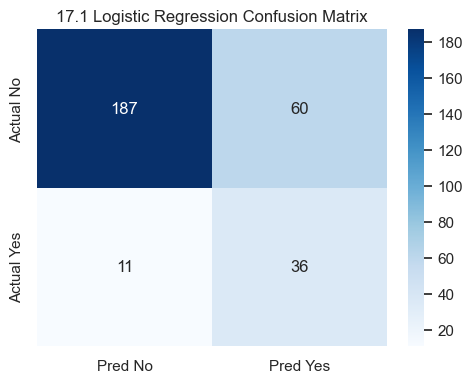

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# Reuse the scaler fit on training data and evaluate on holdout test set
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr.fit(X_res, y_res)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred),
    'ROC_AUC': roc_auc_score(y_test, lr_prob),
}

print('Logistic Regression Metrics:')
print(pd.Series(lr_metrics).drop('Model'))
print('\nClassification Report:\n')
print(classification_report(y_test, lr_pred, target_names=['No Attrition', 'Attrition']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title('17.1 Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

### 17.2 Random Forest
**Why use it:**
- Captures non-linear relationships and feature interactions.
- Often strong performance on tabular HR datasets.
- Feature importance gives practical insight into key drivers.

Random Forest Metrics:
Accuracy     0.836735
Precision    0.428571
Recall        0.06383
F1           0.111111
ROC_AUC      0.790077
dtype: object

Classification Report:

              precision    recall  f1-score   support

No Attrition       0.85      0.98      0.91       247
   Attrition       0.43      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.64      0.52      0.51       294
weighted avg       0.78      0.84      0.78       294



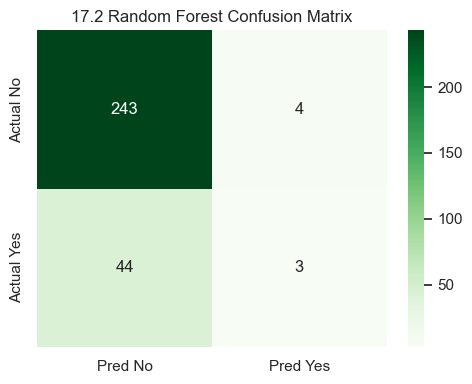

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred),
    'ROC_AUC': roc_auc_score(y_test, rf_prob),
}

print('Random Forest Metrics:')
print(pd.Series(rf_metrics).drop('Model'))
print('\nClassification Report:\n')
print(classification_report(y_test, rf_pred, target_names=['No Attrition', 'Attrition']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title('17.2 Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

### 17.3 Support Vector Machine (SVM)
**Why use it:**
- Strong margin-based classifier that works well on complex boundaries.
- Effective on high-dimensional spaces after scaling.
- Good option when class boundaries are not purely linear.

SVM Metrics:
Accuracy     0.833333
Precision    0.477273
Recall       0.446809
F1           0.461538
ROC_AUC      0.759842
dtype: object

Classification Report:

              precision    recall  f1-score   support

No Attrition       0.90      0.91      0.90       247
   Attrition       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294



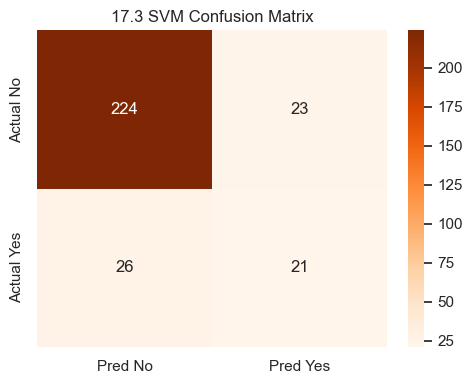

Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                            
Logistic Regression    0.7585     0.3750  0.7660  0.5035   0.7958
SVM (RBF)              0.8333     0.4773  0.4468  0.4615   0.7598
Random Forest          0.8367     0.4286  0.0638  0.1111   0.7901


In [14]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_res, y_res)

svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

svm_metrics = {
    'Model': 'SVM (RBF)',
    'Accuracy': accuracy_score(y_test, svm_pred),
    'Precision': precision_score(y_test, svm_pred),
    'Recall': recall_score(y_test, svm_pred),
    'F1': f1_score(y_test, svm_pred),
    'ROC_AUC': roc_auc_score(y_test, svm_prob),
}

print('SVM Metrics:')
print(pd.Series(svm_metrics).drop('Model'))
print('\nClassification Report:\n')
print(classification_report(y_test, svm_pred, target_names=['No Attrition', 'Attrition']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.title('17.3 SVM Confusion Matrix')
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame([lr_metrics, rf_metrics, svm_metrics]).set_index('Model')
print('Model Comparison:')
print(comparison_df.sort_values(by=['F1', 'Recall'], ascending=False).round(4))

## 18) Hyperparameter Tuning with RandomizedSearchCV
This section tunes all three selected models using RandomizedSearchCV only.

Why RandomizedSearchCV was chosen:
- More efficient than exhaustive grid search for larger parameter spaces.
- Finds strong hyperparameters with lower computation cost.
- Provides practical control over runtime through n_iter.

Models tuned:
- Logistic Regression (RandomizedSearchCV)
- Random Forest (RandomizedSearchCV)
- SVM (RBF, RandomizedSearchCV)

Selection metric: F1 score (focus on the imbalanced positive attrition class).

In [15]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, loguniform

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Helper for consistent evaluation on holdout test data
def evaluate_model(name, estimator, X_eval, y_eval):
    pred = estimator.predict(X_eval)
    prob = estimator.predict_proba(X_eval)[:, 1]
    return {
        'Model': name,
        'Precision': precision_score(y_eval, pred),
        'Recall': recall_score(y_eval, pred),
        'F1': f1_score(y_eval, pred),
        'ROC_AUC': roc_auc_score(y_eval, prob),
    }

# 1) Logistic Regression tuning (RandomizedSearchCV)
lr_dist = {
    'C': loguniform(1e-2, 1e2),
    'solver': ['lbfgs', 'liblinear']
}

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42),
    param_distributions=lr_dist,
    n_iter=12,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
lr_search.fit(X_res, y_res)

print('Best Logistic Regression Params:', lr_search.best_params_)
print('Best CV F1:', round(lr_search.best_score_, 4))

# 2) Random Forest tuning (RandomizedSearchCV)
rf_dist = {
    'n_estimators': randint(200, 900),
    'max_depth': [None, 6, 10, 14, 18, 24],
    'min_samples_split': randint(2, 12),
    'min_samples_leaf': randint(1, 6),
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_dist,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('\nBest Random Forest Params:', rf_search.best_params_)
print('Best CV F1:', round(rf_search.best_score_, 4))

# 3) SVM tuning (RandomizedSearchCV)
svm_dist = {
    'C': loguniform(1e-2, 1e2),
    'gamma': loguniform(1e-4, 1e0),
    'kernel': ['rbf']
}

svm_search = RandomizedSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, random_state=42),
    param_distributions=svm_dist,
    n_iter=15,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
svm_search.fit(X_res, y_res)

print('\nBest SVM Params:', svm_search.best_params_)
print('Best CV F1:', round(svm_search.best_score_, 4))

# Evaluate tuned models on holdout test set
tuned_lr_metrics = evaluate_model('Logistic Regression ', lr_search.best_estimator_, X_test_scaled, y_test)
tuned_rf_metrics = evaluate_model('Random Forest ', rf_search.best_estimator_, X_test, y_test)
tuned_svm_metrics = evaluate_model('SVM ', svm_search.best_estimator_, X_test_scaled, y_test)

tuned_comparison = pd.DataFrame([
    tuned_lr_metrics,
    tuned_rf_metrics,
    tuned_svm_metrics,
]).set_index('Model').sort_values(by=['F1', 'Recall'], ascending=False)

print('\nTuned Model Comparison (sorted by F1 then Recall):')
print(tuned_comparison.round(4))

Best Logistic Regression Params: {'C': np.float64(0.017073967431528128), 'solver': 'liblinear'}
Best CV F1: 0.7765

Best Random Forest Params: {'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 401}
Best CV F1: 0.4504

Best SVM Params: {'C': np.float64(2.5378155082656657), 'gamma': np.float64(0.06796578090758151), 'kernel': 'rbf'}
Best CV F1: 0.9645

Tuned Model Comparison (sorted by F1 then Recall):
                      Precision  Recall      F1  ROC_AUC
Model                                                   
Logistic Regression      0.3564  0.7660  0.4865   0.7965
Random Forest            0.4878  0.4255  0.4545   0.7851
SVM                      0.6818  0.3191  0.4348   0.7607


## 19) Model Results Interpretation and Performance Comparison
### Interpretation of Tuned Results
- **Logistic Regression (Tuned)** has the highest **Recall** and highest **F1**, making it the best option when the priority is catching as many attrition cases as possible.
- **Random Forest (Tuned)** provides a more balanced precision-recall tradeoff than SVM, but lower F1 than Logistic Regression.
- **SVM (Tuned)** has the highest **Precision**, meaning fewer false positives, but lower recall, so it misses more true attrition cases.
- For HR intervention use-cases where missing at-risk employees is costly, **Logistic Regression (Tuned)** is the strongest practical choice.

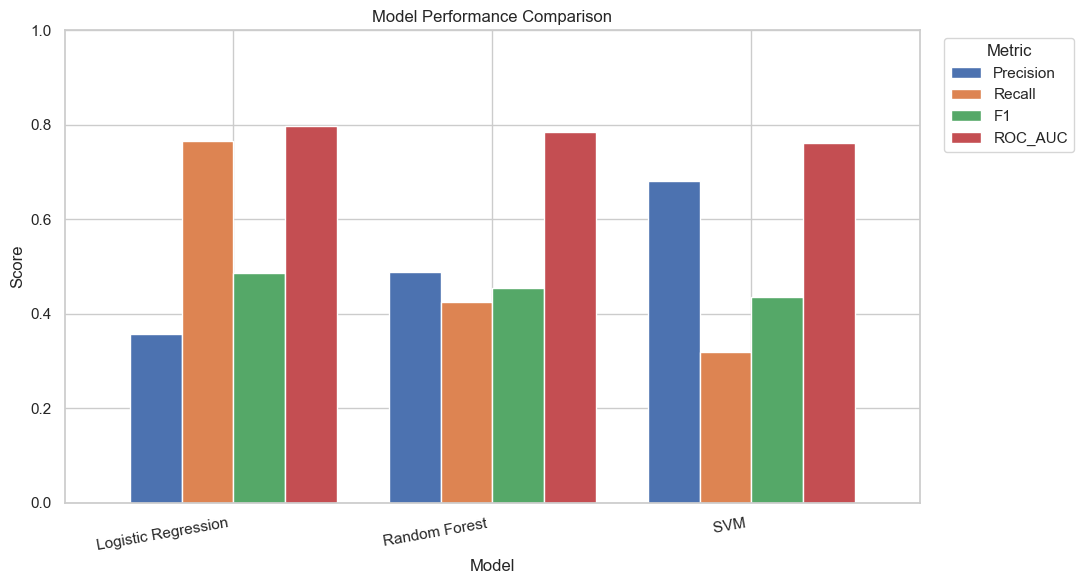

Summary (higher is better):
                      Precision  Recall      F1  ROC_AUC
Model                                                   
Logistic Regression      0.3564  0.7660  0.4865   0.7965
Random Forest            0.4878  0.4255  0.4545   0.7851
SVM                      0.6818  0.3191  0.4348   0.7607


In [16]:
# Graphical comparison of tuned model performance (excluding Accuracy)
plot_df = tuned_comparison[['Precision', 'Recall', 'F1', 'ROC_AUC']].copy()

ax = plot_df.plot(kind='bar', figsize=(11, 6), width=0.8)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

print('Summary (higher is better):')
print(plot_df.round(4))

## 20) ROC Curve — Logistic Regression
The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate across all classification thresholds. A higher AUC indicates stronger model discrimination.

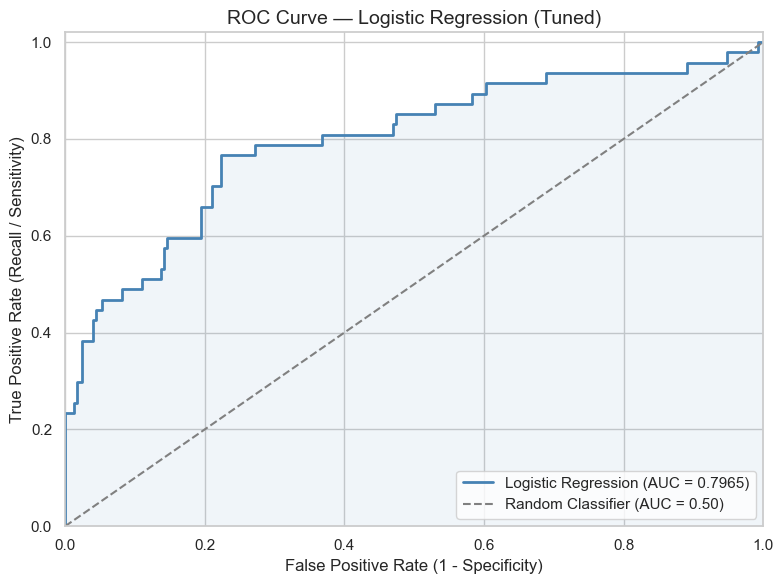

ROC-AUC: 0.7965


In [17]:
from sklearn.metrics import roc_curve, auc

# Get probabilities from tuned Logistic Regression on scaled test set
y_prob_lr = lr_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curve — Logistic Regression (Tuned)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')


## 21) Confusion Matrix — All Tuned Models Comparison
Shows the exact counts of correct and incorrect predictions on the test set for each model.
- **True Negatives (TN):** Correctly predicted stayed
- **False Positives (FP):** Predicted left, actually stayed
- **False Negatives (FN):** Predicted stayed, actually left *(most costly)*
- **True Positives (TP):** Correctly predicted left

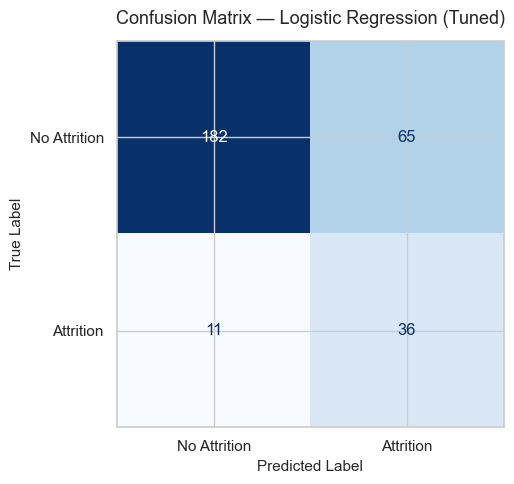

True Negatives  (TN): 182  — stayed, predicted stayed
False Positives (FP): 65  — stayed, predicted left
False Negatives (FN): 11  — left, predicted stayed  <- most costly
True Positives  (TP): 36  — left, predicted left

Recall    = 0.7660
Precision = 0.3564


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use tuned models if available, otherwise fall back to base models
try:
    model_lr = lr_search.best_estimator_
    model_rf = rf_search.best_estimator_
    model_svm = svm_search.best_estimator_
    suffix = '(Tuned)'
except NameError:
    model_lr = lr
    model_rf = rf_model
    model_svm = svm
    suffix = '(Base)'

models = [
    (f'Logistic Regression {suffix}', model_lr, X_test_scaled, 'Blues'),
    (f'Random Forest {suffix}',       model_rf, X_test,        'Greens'),
    (f'SVM {suffix}',                 model_svm, X_test_scaled, 'Oranges'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix Comparison — All Tuned Models', fontsize=14, y=1.02)

summary_rows = []
for ax, (name, model, X_eval, cmap) in zip(axes, models):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Attrition', 'Attrition']
    ).plot(ax=ax, colorbar=False, cmap=cmap)

    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

    summary_rows.append({
        'Model': name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Recall':    round(tp / (tp + fn), 4),
        'Precision': round(tp / (tp + fp), 4),
        'Missed (FN)': fn,
        'False Alarms (FP)': fp,
    })

plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('\nConfusion Matrix Summary — All Models:')
print(summary_df.to_string())
print('\nKey: FN = missed attrition cases (most costly) | FP = false alarms')
